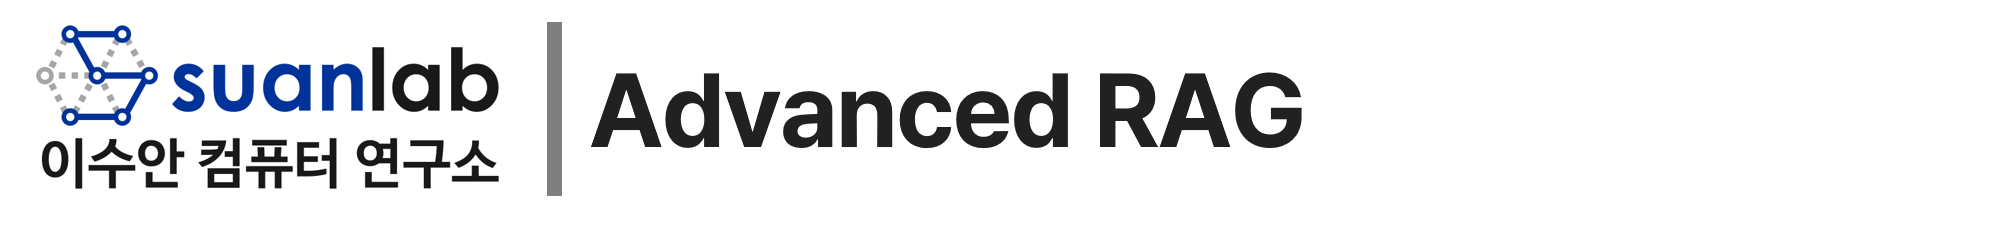

# 📈 RAG 운영 모니터링 — 골든셋 회귀·비용

## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" sentence-transformers faiss-cpu pandas matplotlib

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 22.9 MB/s eta 0:00:00
Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


# RAG 운영 모니터링 (골든셋 회귀 감지)

> **"배포 후가 진짜 시작 — 골든셋을 주기적으로 재실행해 품질 회귀를 감지한다."**

- RAG는 한 번 잘 만든다고 끝이 아님
- 모델 교체·프롬프트 수정·데이터 추가·라이브러리 업데이트가 조용히 품질을 **떨어뜨릴(회귀, regression)** 수 있음
- 그래서 운영에서는 **고정된 평가셋(골든셋)** 을
**주기적으로 다시 돌려** 점수가 떨어지지 않았는지 감시 필요

**학습 목표**
1. 같은 골든셋을 **두 '버전'**(약한 RAG v1 ↔ 개선 RAG v2)에 돌려 점수를 비교
2. Claude **judge**(faithfulness/answer_relevancy)와 검색 **Hit@k** 로 버전별 품질을 수치화
3. 여러 '날짜' 스냅샷을 합성해 **시간축 drift(점수 흐름)** 를 시계열 표·그래프로 추적
4. **임계선**을 그어 **회귀를 자동 감지**(경보 플래그)하는 로직을 만들기
5. **prompt caching / Batches** 로 평가 비용을 줄이는 미니 대시보드(패턴)를 봄

## 용어 미니 사전 (운영 모니터링 편)

| 용어 | 한 줄 뜻 |
|---|---|
| 골든셋(golden set) | 정답을 사람이 미리 확정해 둔 **고정 평가 질문 모음**. 매번 같은 잣대로 채점하는 기준자 |
| 회귀(regression) | 잘 되던 것이 어떤 변경 뒤 **다시 나빠지는 현상**. "품질 회귀 감지"가 모니터링의 핵심 |
| drift(드리프트) | 시간이 지나며 점수가 **서서히/갑자기 변하는 흐름**. 시계열로 봐야 보임 |
| faithfulness | 답이 **근거(검색된 문서)에 충실**한가(환각 없이). 1~5점 |
| answer_relevancy | 답이 **질문에 적합**한가(동문서답 아님). 1~5점 |
| Hit@k | 정답 근거 문서가 **상위 k개 검색 결과 안에 들었는가**(검색 성공률) |
| 임계선(threshold) | "이 점수 아래로 내려가면 경보" 하는 **기준선**. 그래프의 빨간 가로선 |
| prompt caching | 안 바뀌는 앞부분(지침·근거)을 **캐시**해 반복 호출 비용을 줄이는 기능(최대 90%↓). |
| Batches API | 평가 수백 건을 **비동기 일괄**로 돌려 50% 할인받는 기능(즉시 응답 아님) |

> 쉽게 말하면 골든셋은 '학교 기말고사 문제지(정답 포함)'  
시스템을 바꿀 때마다 같은 문제지로 시험을 다시 쳐서 **점수가 떨어졌는지** 확인하는 게 운영 모니터링

## 합성 코퍼스 + 골든 QA셋

### 개념 복습
- 모니터링의 출발점은 **변하지 않는 골든셋**
- 질문, 정답 근거 문서, 정답 키워드를 고정해 두고
시스템을 바꿀 때마다 **같은 잣대**로 채점

### 가상 코퍼스와 골든 QA셋 정의
- 가상의 사내 위키 문서 모음(`DOCS`)과, 정답을 미리 확정한 평가 질문 모음(`GOLD`)을 생성
- `gold`는 정답 근거가 들어 있는 문서 번호, `kw`는 정답에 꼭 들어가야 할 키워드

In [3]:
# 합성(가상) 사내 위키 코퍼스 — 실제 회사 아님. multi-hop도 일부 포함해 검색 난이도 차이를 만든다.
DOCS = [
    "노바테크의 2023년 연매출은 1조 2천억 원이다.",                       # 0
    "노바테크 CEO는 김하늘이며 AI 가속기 사업을 총괄한다.",               # 1
    "그린모빌리티는 리튬인산철(LFP) 배터리를 만드는 전기차 부품 회사다.",  # 2
    "퀀텀칩은 데이터센터용 AI 칩 시장에서 노바테크와 경쟁한다.",          # 3
    "정밀소재는 노바테크와 퀀텀칩에 부품을 대는 공통 공급사다.",          # 4
    "노바소프트는 노바테크의 클라우드 소프트웨어 자회사다.",              # 5
    "그린모빌리티 CFO 박서준은 2024년 IPO(상장)를 준비 중이다.",         # 6
    "환불 정책: 구매 후 14일 이내, 미개봉 제품에 한해 전액 환불된다.",    # 7
    "배송 정책: 주문 후 평균 2영업일 내 출고되며 도서산간은 1일 추가된다.",# 8
    "멤버십 등급은 실버·골드·플래티넘 3단계이며 골드부터 무료배송이다.",  # 9
]

# 골든 QA셋: q=질문, gold=정답 근거 문서 번호, kw=정답에 들어가야 할 키워드
GOLD = [
    {"q": "노바테크 CEO는 누구인가?",            "gold": [1],    "kw": "김하늘"},
    {"q": "환불은 며칠 안에 가능한가?",          "gold": [7],    "kw": "14일"},
    {"q": "그린모빌리티는 어떤 배터리를 만드나?", "gold": [2],    "kw": "리튬인산철"},
    {"q": "골드 등급의 혜택은?",                 "gold": [9],    "kw": "무료배송"},
    {"q": "노바테크의 경쟁사는?",                "gold": [3],    "kw": "퀀텀칩"},
    {"q": "노바테크의 공급사이면서 퀀텀칩에도 납품하는 회사는?", "gold": [4], "kw": "정밀소재"},
]
print(f"코퍼스 {len(DOCS)}문서, 골든셋 {len(GOLD)}문항 준비 완료")

코퍼스 10문서, 골든셋 6문항 준비 완료


## 두 '버전'의 RAG (v1 약함 ↔ v2 개선)

### 개념 복습
- 운영에서 회귀는 보통 **"버전을 바꿨더니 점수가 떨어졌다"** 로 나타남
- 그래서 비교할 두 버전을 생성
- **v1 (약한 RAG)**: 검색 `k=1`(근거를 거의 못 모음) + **문맥을 거의 안 주는** 빈약한 프롬프트
- **v2 (개선 RAG)**: 검색 `k=4`(근거 충분) + 근거에 충실히 답하라는 **제대로 된 프롬프트**
- self-contained 경량으로, 같은 임베딩 인덱스를 공유하고 **검색 k와 프롬프트만** 다르게 함

### 임베딩 검색 인덱스 만들기
- 문서를 숫자(임베딩)로 바꿔 FAISS 인덱스에 넣음
- 질문을 주면 가장 비슷한 문서 k개를 돌려줌

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np, faiss

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")  # 임베딩=비-Claude(경량 다국어)
def embed(texts):
    return np.array(embedder.encode(texts, normalize_embeddings=True), dtype="float32")

DOC_EMB = embed(DOCS)
index = faiss.IndexFlatIP(DOC_EMB.shape[1])   # 정규화 임베딩 → 내적 = 코사인 유사도
index.add(DOC_EMB)

def search(query, k=4):
    """질문과 가장 비슷한 문서 번호 k개(랭킹 순)를 돌려준다."""
    q = embed([query]); _, idx = index.search(q, min(k, len(DOCS)))
    return [int(i) for i in idx[0]]

print("인덱스 준비 완료. 시험 검색:", search("노바테크 CEO", k=3))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

인덱스 준비 완료. 시험 검색: [1, 5, 6]


### 두 버전 RAG 답변 함수
- `rag_v1`은 약한 설정(k=1, 빈약 프롬프트), `rag_v2`는 개선 설정(k=4, 충실 프롬프트)으로 답을 생성
- 나중에 같은 골든셋을 두 함수에 돌려 점수를 비교

In [5]:
# 공통 생성 유틸
def ask_claude(prompt, system, max_tokens=400):
    msg = client.messages.create(model=MODEL, max_tokens=max_tokens,
        system=system, messages=[{"role": "user", "content": prompt}])
    return msg.content[0].text

# --- v1: 약한 RAG (k=1, 문맥 거의 없음) ---
def rag_v1(question):
    ids = search(question, k=1)                 # 근거를 1개만 → 자주 놓침
    ctx = DOCS[ids[0]] if ids else ""
    sys = "질문에 짧게 답하라."                  # 빈약한 지침(근거 충실 요구 없음)
    ans = ask_claude(f"질문: {question}\n참고(있으면): {ctx}", system=sys)
    return {"answer": ans, "ctx_ids": ids, "ctx": [DOCS[i] for i in ids]}

# --- v2: 개선 RAG (k=4, 근거 충실 프롬프트) ---
def rag_v2(question):
    ids = search(question, k=4)                 # 근거를 넉넉히
    ctx = "\n".join(f"- {DOCS[i]}" for i in ids)
    sys = ("너는 RAG 도우미다. 아래 '근거'에 적힌 내용에만 기반해 한국어로 정확히 답하라. "
           "근거에 없으면 모른다고 답하라.")
    ans = ask_claude(f"질문: {question}\n근거:\n{ctx}", system=sys)
    return {"answer": ans, "ctx_ids": ids, "ctx": [DOCS[i] for i in ids]}

RAG_VERSIONS = {"v1_weak": rag_v1, "v2_improved": rag_v2}
print("두 버전 준비:", list(RAG_VERSIONS))
print("v1 데모:", rag_v1(GOLD[0]["q"])["answer"][:60], "...")

두 버전 준비: ['v1_weak', 'v2_improved']
v1 데모: 노바테크 CEO는 **김하늘**입니다. ...


## 같은 골든셋을 두 버전에 돌려 채점 (judge + Hit@k)

### 개념 복습
- **검색 품질**: 정답 근거 문서가 상위 k에 들었는가 → **Hit@k**(0/1)
- **생성 품질**: 답이 근거에 충실한가(**faithfulness**) + 질문에 적합한가(**answer_relevancy**) → Claude **judge**

judge는 `tool_use`로 **점수 스키마를 강제**해 항상 같은 형식(JSON)으로 받음

### Claude judge(점수 강제) 정의
- RAG 답변을 1~5점으로 채점하는 judge
- `tool_choice`로 도구를 강제해 reasoning→점수 형식을 보장

In [6]:
# 정확도가 더 필요하면 이 judge 셀의 모델을 MODEL_JUDGE = "claude-opus-4-8" 로 한 줄 상향 가능(기본은 비용 위해 sonnet 4.6).
MODEL_JUDGE = MODEL
JUDGE_TOOL = [{
  "name": "report_judgment",
  "description": "RAG 답변을 평가한 결과를 보고",
  "input_schema": {"type": "object", "properties": {
      "reasoning": {"type": "string", "description": "채점 근거(먼저 생각)"},
      "faithfulness": {"type": "integer", "description": "1-5, 근거 충실도(환각 없음)"},
      "answer_relevancy": {"type": "integer", "description": "1-5, 질문 적합도"},
  }, "required": ["reasoning", "faithfulness", "answer_relevancy"]}
}]

def judge(question, answer, contexts):
    ctx = "\n".join(contexts) if contexts else "(근거 없음)"
    msg = client.messages.create(
        model=MODEL_JUDGE, max_tokens=600,
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content":
            f"질문:{question}\n근거:{ctx}\n답변:{answer}\n"
            "rubric에 따라 1-5로 채점하라. reasoning을 먼저 쓴 뒤 점수를 매겨라."}],
    )
    for b in msg.content:
        if b.type == "tool_use":
            return b.input
    return {"faithfulness": 3, "answer_relevancy": 3, "reasoning": "(파싱 실패 기본값)"}

print("judge 데모:", judge(GOLD[0]["q"], "노바테크 CEO는 김하늘이다.", [DOCS[1]]))

judge 데모: {'reasoning': '**근거 충실도(Faithfulness):** 근거 문서에 "노바테크 CEO는 김하늘이며 AI 가속기 사업을 총괄한다"고 명시되어 있으며, 답변은 "노바테크 CEO는 김하늘이다"라고 정확히 근거에 기반하여 서술하였다. 근거에 없는 내용을 추가하거나 왜곡한 부분이 없으므로 환각이 전혀 없다. → 5점\n\n**질문 적합도(Answer Relevancy):** 질문은 "노바테크 CEO는 누구인가?"이며, 답변은 "노바테크 CEO는 김하늘이다"로 질문에 완전히 직접적으로 답하고 있다. 불필요한 정보나 누락 없이 핵심만 간결하게 전달하고 있다. → 5점', 'faithfulness': 5, 'answer_relevancy': 5}


### 한 버전을 골든셋 전체로 평가
- 예상 호출: golden 6문항 × (생성 1 + judge 1) = **버전당 약 12회 Claude 호출**
- 두 버전 → 약 24회 (Sonnet 4.6 기준 매우 저렴하지만, 이후 caching/Batches 절감 패턴을 다룸)

In [7]:
def hit_at_k(gold_ids, ctx_ids):
    """정답 근거 문서가 검색 결과 안에 하나라도 있으면 1, 아니면 0."""
    return 1 if any(g in ctx_ids for g in gold_ids) else 0

def evaluate_version(rag_fn):
    """한 RAG 버전을 골든셋 전체로 채점 → 평균 지표 dict 반환."""
    hits, faiths, rels, kw_ok = [], [], [], []
    for item in GOLD:
        out = rag_fn(item["q"])
        hits.append(hit_at_k(item["gold"], out["ctx_ids"]))
        kw_ok.append(1 if item["kw"] in out["answer"] else 0)   # 정답 키워드 포함(정확도 근사)
        j = judge(item["q"], out["answer"], out["ctx"])
        faiths.append(j["faithfulness"]); rels.append(j["answer_relevancy"])
    return {
        "hit@k":            round(float(np.mean(hits)), 3),
        "keyword_acc":      round(float(np.mean(kw_ok)), 3),
        "faithfulness":     round(float(np.mean(faiths)), 3),
        "answer_relevancy": round(float(np.mean(rels)), 3),
    }

print("buildable: evaluate_version 정의 완료 (다음 셀에서 두 버전 실행)")

buildable: evaluate_version 정의 완료 (다음 셀에서 두 버전 실행)


### 두 버전 점수 비교(표)
- 약한 v1과 개선 v2의 점수를 나란히 봄
- 보통 **v2가 모든 지표에서 높게** 나옴

In [8]:
import pandas as pd

scores_by_version = {name: evaluate_version(fn) for name, fn in RAG_VERSIONS.items()}
df_cmp = pd.DataFrame(scores_by_version).T
df_cmp.index.name = "version"
print("=== 버전별 점수 비교 ===")
print(df_cmp)
print("\n해석: v2_improved가 v1_weak보다 검색(hit@k)·생성(faithfulness/relevancy)에서 높으면 정상.")

=== 버전별 점수 비교 ===
             hit@k  keyword_acc  faithfulness  answer_relevancy
version                                                        
v1_weak        1.0          1.0           5.0               5.0
v2_improved    1.0          1.0           5.0               5.0

해석: v2_improved가 v1_weak보다 검색(hit@k)·생성(faithfulness/relevancy)에서 높으면 정상.


### 버전 비교 막대그래프
- **그림에서 볼 점**: 막대가 높을수록 좋은 점수. v2(개선)의 막대가 v1(약함)보다 전반적으로 높으면
"개선이 실제로 효과가 있었다"는 뜻
- faithfulness/relevancy는 1 ~ 5, hit@k/keyword_acc는 0 ~ 1 척도라 따로 봄

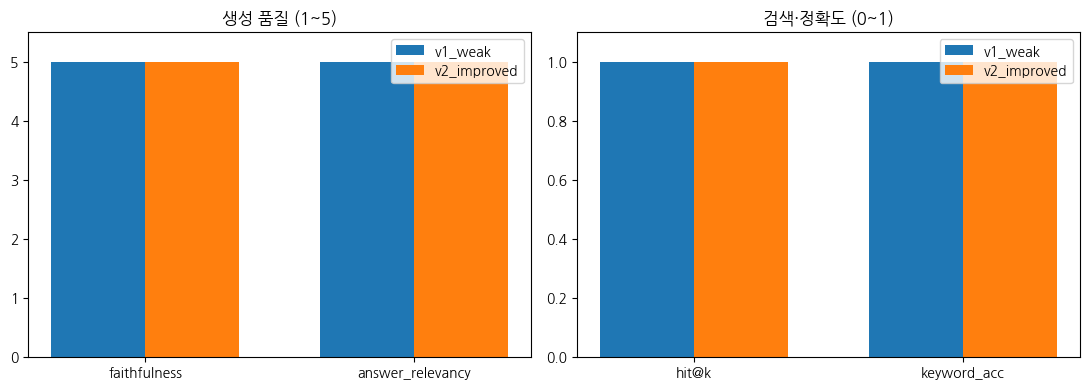

In [9]:
import numpy as np
metrics_5 = ["faithfulness", "answer_relevancy"]
metrics_1 = ["hit@k", "keyword_acc"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metrics, title, ymax in [(axes[0], metrics_5, "생성 품질 (1~5)", 5),
                                  (axes[1], metrics_1, "검색·정확도 (0~1)", 1)]:
    x = np.arange(len(metrics)); w = 0.35
    for j, name in enumerate(RAG_VERSIONS):
        vals = [scores_by_version[name][m] for m in metrics]
        ax.bar(x + (j-0.5)*w, vals, w, label=name)
    ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, ymax*1.1)
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 시간축 drift 추적 (여러 '날짜' 스냅샷)

### 개념 복습
- 운영에서는 점수를 **한 번만 보지 않고** 매일/매주 기록해 **흐름(추세)** 을 봄
- 갑자기 뚝 떨어지면 어떤 배포가 회귀를 일으켰다는 신호
- 여기서는 매번 Claude를 다시 부르지 않고, 현실적인 운영 로그처럼 **여러 날짜의 스냅샷을 합성**해 시계열로 생성 (약간의 잡음 포함)

### 일자별 점수 스냅샷 합성
- 방금 측정한 v2 점수를 기준(baseline)으로, 6일치 운영 로그를 생성
- **3일째에 어떤 배포로 faithfulness가 급락**하는 회귀 사건을 시나리오로 심음(데모용 합성)

In [10]:
import numpy as np, pandas as pd
rng = np.random.default_rng(42)

base = scores_by_version["v2_improved"]   # 운영 중인 버전(v2)을 기준선으로
dates = ["06-01", "06-02", "06-03", "06-04", "06-05", "06-06"]

# 합성 운영 로그: 평소엔 기준선 ± 작은 잡음, 단 06-04(인덱스 3)에 '회귀 배포' → faithfulness 급락 후 점진 회복
rows = []
for d_i, d in enumerate(dates):
    noise = lambda v: round(float(np.clip(v + rng.normal(0, 0.06), 0, 5 if v > 1.5 else 1)), 3)
    faith = base["faithfulness"]
    if d_i == 3:   faith = base["faithfulness"] - 1.3     # 회귀 사건!
    elif d_i == 4: faith = base["faithfulness"] - 0.7     # 부분 회복
    rows.append({
        "date": d,
        "faithfulness":     noise(faith),
        "answer_relevancy": noise(base["answer_relevancy"]),
        "hit@k":            noise(base["hit@k"]),
    })
ts = pd.DataFrame(rows).set_index("date")
print("=== 일자별 골든셋 점수 스냅샷(운영 로그·합성) ===")
print(ts)

=== 일자별 골든셋 점수 스냅샷(운영 로그·합성) ===
       faithfulness  answer_relevancy  hit@k
date                                        
06-01         5.000             4.938  1.000
06-02         5.000             4.883  0.922
06-03         5.000             4.981  0.999
06-04         3.649             5.000  1.000
06-05         4.304             5.000  1.000
06-06         4.948             5.000  0.942


### 시계열 라인그래프 + 임계선
- **그림에서 볼 점**: 선이 위로 평탄하면 건강, **아래로 꺾이며 빨간 임계선 밑으로 내려가면 회귀**
- faithfulness 선이 06-04에서 빨간선 아래로 떨어지는 게 보이면 모니터링이 회귀를 '눈으로' 잡은 것

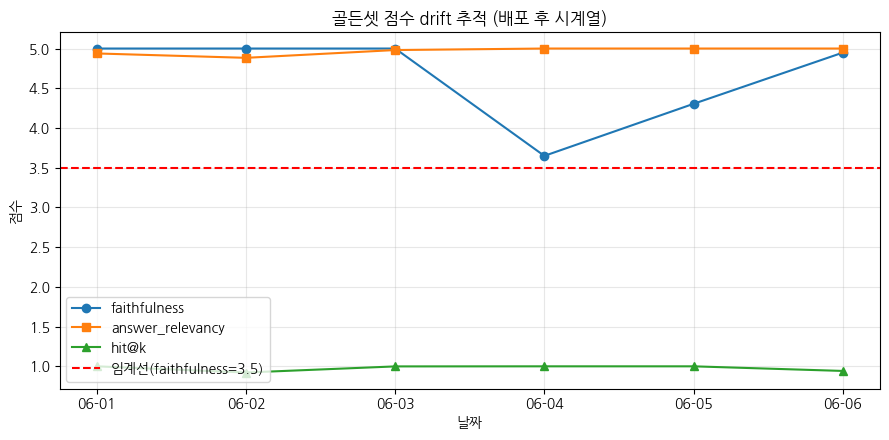

In [11]:
FAITH_THRESHOLD = 3.5   # faithfulness가 이 아래면 경보(운영 기준선, 도메인에 맞게 조정)

plt.figure(figsize=(9, 4.5))
for col, marker in [("faithfulness", "o"), ("answer_relevancy", "s"), ("hit@k", "^")]:
    plt.plot(ts.index, ts[col], marker=marker, label=col)
plt.axhline(FAITH_THRESHOLD, color="red", linestyle="--",
            label=f"임계선(faithfulness={FAITH_THRESHOLD})")
plt.title("골든셋 점수 drift 추적 (배포 후 시계열)")
plt.ylabel("점수"); plt.xlabel("날짜"); plt.legend(loc="lower left"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 회귀 자동 감지 (임계선 + 경보 플래그)

### 개념 복습
- 사람이 매일 그래프를 노려볼 수는 없음
- 그래서 **규칙**으로 자동 판정
  1. **절대 기준 위반**: 점수가 임계선 아래로 내려갔는가?
  2. **상대 하락(전일 대비)**: 어제보다 일정 폭 이상 급락했는가?
- 둘 중 하나라도 걸리면 **경보 플래그**를 올림

### 회귀 감지 함수 + 일자별 경보 표
- 각 날짜에 대해 임계선 위반·급락 여부를 계산해 `alert`(True/False) 플래그를 붙임

In [12]:
def detect_regression(ts_df, col="faithfulness", threshold=FAITH_THRESHOLD, drop=0.5):
    """절대 임계선 위반 또는 전일 대비 drop 이상 급락 시 회귀로 플래그."""
    flags = []
    prev = None
    for d, v in ts_df[col].items():
        below = v < threshold                        # 절대 기준 위반
        crash = (prev is not None) and (prev - v >= drop)  # 전일 대비 급락
        flags.append({"date": d, col: v, "below_threshold": bool(below),
                      "day_drop": bool(crash), "alert": bool(below or crash)})
        prev = v
    return pd.DataFrame(flags).set_index("date")

reg = detect_regression(ts, col="faithfulness")
print("=== 회귀 감지 결과 ===")
print(reg)
alerts = reg.index[reg["alert"]].tolist()
print(f"\n경보 발생 날짜: {alerts if alerts else '없음(건강)'}")

=== 회귀 감지 결과 ===
       faithfulness  below_threshold  day_drop  alert
date                                                 
06-01         5.000            False     False  False
06-02         5.000            False     False  False
06-03         5.000            False     False  False
06-04         3.649            False      True   True
06-05         4.304            False     False  False
06-06         4.948            False     False  False

경보 발생 날짜: ['06-04']


> **읽는 법**: `below_threshold`=임계선 아래, `day_drop`=전일 대비 급락, `alert`=둘 중 하나라도 참  
> 운영에서는 `alert`가 True인 순간 Slack/이메일로 알림을 보내고, 직전 배포를 의심해 롤백을 검토

### 실무 포인트
- 임계선은 **도메인별로** 다름(의료/법률은 faithfulness 기준을 더 높게)
- 단일 지표만 보지 말고 **검색(hit@k) + 생성(faithfulness/relevancy)** 을 함께 추적
- 회귀가 잡히면 **그 골든셋 문항의 실제 답**을 열어 무엇이 틀렸는지 사람이 확인 (원인 분석)

## 평가 비용 절감 미니 대시보드 (caching / Batches)

### 개념 복습
- 골든셋을 **매일 수백 건** 돌리면 judge 호출 비용이 쌓임
- **prompt caching**: judge의 **안 바뀌는 앞부분**(rubric·공통 지침)을 캐시 → 두 번째부터 거의 공짜(최대 90%↓).
- **Batches API**: 골든셋 전체를 **비동기 일괄**로 채점 → 모든 토큰 50% 할인(단, 즉시 응답 아님 → 야간 회귀평가에 적합).

### prompt caching judge 패턴(반복 prefix 캐시)
- rubric을 `system` 블록에 두고 `cache_control`을 걸어, 같은 rubric으로 여러 문항을 채점할 때 비용을 줄임
- 아래는 패턴 예시 — 실제 절감은 같은 prefix를 반복 호출할 때 발생

In [13]:
SYSTEM_RUBRIC = ("너는 RAG 평가자다. 답변을 근거에 대한 faithfulness(1-5)와 "
                 "질문 적합도 answer_relevancy(1-5)로 채점한다. reasoning을 먼저 쓴다.")

def judge_cached(question, answer, contexts):
    # 핵심: 안 바뀌는 rubric을 system 앞에 두고 cache_control → 반복 채점 시 prefix 캐시 적중(최대 90%↓)
    msg = client.messages.create(
        model=MODEL_JUDGE, max_tokens=600,
        system=[{"type": "text", "text": SYSTEM_RUBRIC,
                 "cache_control": {"type": "ephemeral"}}],   # ← 캐시 대상(고정 rubric)
        tools=JUDGE_TOOL, tool_choice={"type": "tool", "name": "report_judgment"},
        messages=[{"role": "user", "content":
            f"질문:{question}\n근거:{chr(10).join(contexts)}\n답변:{answer}"}],
    )
    for b in msg.content:
        if b.type == "tool_use":
            return b.input
    return None

print("caching judge 데모:", judge_cached(GOLD[0]["q"], "노바테크 CEO는 김하늘이다.", [DOCS[1]]))

caching judge 데모: {'reasoning': '근거에 "노바테크 CEO는 김하늘이며 AI 가속기 사업을 총괄한다"고 명시되어 있으며, 답변은 "노바테크 CEO는 김하늘이다"로 근거에 충실하게 작성되었다. 환각 없이 근거 내용을 정확히 반영하였으므로 faithfulness는 5점이다. 질문은 "노바테크 CEO는 누구인가?"이고 답변은 CEO가 김하늘임을 직접적으로 답하고 있어 질문에 완전히 적합하다. answer_relevancy도 5점이다.', 'faithfulness': 5, 'answer_relevancy': 5}


### Batches API 패턴(야간 대량 회귀평가)
- `RUN_BATCH=False` 가드로 **실행하지 않고 패턴만** 보여줌 (완료까지 최대 24h라 실습 부적합)
- 실제 운영에서는 골든셋 수백 건을 한 번에 제출해 50% 절감하고, 다음 날 결과를 취합

In [14]:
RUN_BATCH = False   # 비동기(최대 24h) → 실습에선 패턴만. 야간 회귀평가에 적합.

def judge_prompt(item, answer, contexts):
    return (f"질문:{item['q']}\n근거:{chr(10).join(contexts)}\n답변:{answer}\n"
            "faithfulness(1-5), answer_relevancy(1-5)로 채점하라.")

if RUN_BATCH:
    # 모든 토큰 50% 할인 · 비동기. 골든셋 전체를 한 번에 채점.
    requests = []
    for i, item in enumerate(GOLD):
        out = rag_v2(item["q"])
        requests.append({"custom_id": f"q{i}",
            "params": {"model": MODEL_JUDGE, "max_tokens": 512,
                       "tools": JUDGE_TOOL,
                       "tool_choice": {"type": "tool", "name": "report_judgment"},
                       "messages": [{"role": "user",
                                     "content": judge_prompt(item, out["answer"], out["ctx"])}]}})
    batch = client.messages.batches.create(requests=requests)
    print("batch 제출됨:", batch.id, "→ batch.id로 폴링 후 결과 취합(비동기)")
else:
    print("RUN_BATCH=False → Batches 패턴만 표시(실행 안 함). 야간 회귀평가 시 True로.")

RUN_BATCH=False → Batches 패턴만 표시(실행 안 함). 야간 회귀평가 시 True로.


### 비용 절감 미니 대시보드(예상 비용 표)
- 같은 골든셋을 **매일 N일** 채점한다고 가정하고, 동기/캐시/Batches의 상대 비용을 비교 표로 보여줌
- 상대 배수 기반의 교육용 추정치 — 실제 단가는 모델노트의 가격표 참고

In [15]:
import pandas as pd
N_GOLDEN = len(GOLD)
N_DAYS = 30                      # 한 달 매일 회귀평가
calls_per_run = N_GOLDEN        # judge 호출 수(문항당 1)
total_calls = calls_per_run * N_DAYS

dashboard = pd.DataFrame([
    {"방식": "동기(naive)",        "상대비용배수": 1.00, "지연": "즉시", "비고": "기준선"},
    {"방식": "prompt caching",     "상대비용배수": 0.40, "지연": "즉시", "비고": "rubric prefix 캐시(반복분 ~0.1x)"},
    {"방식": "Batches",            "상대비용배수": 0.50, "지연": "비동기(≤24h)", "비고": "야간 일괄"},
    {"방식": "caching + Batches",  "상대비용배수": 0.20, "지연": "비동기", "비고": "둘 다 적용"},
])
dashboard["월간_예상호출"] = total_calls
print(f"가정: 골든셋 {N_GOLDEN}문항 × {N_DAYS}일 = 월 {total_calls}회 judge 호출")
print(dashboard.to_string(index=False))

가정: 골든셋 6문항 × 30일 = 월 180회 judge 호출
               방식  상대비용배수        지연                          비고  월간_예상호출
        동기(naive)     1.0        즉시                         기준선      180
   prompt caching     0.4        즉시 rubric prefix 캐시(반복분 ~0.1x)      180
          Batches     0.5 비동기(≤24h)                       야간 일괄      180
caching + Batches     0.2       비동기                      둘 다 적용      180


> 핵심: 회귀평가는 실시간이 필요 없다 → Batches로 50%↓, 고정 rubric은 caching으로 추가 절감

## 직접 해보기: 임계선을 바꿔 경보 민감도 조정
- 임계선(`threshold`)을 높이면 더 예민하게(작은 하락도 경보), 낮추면 둔하게 반응
- 직접 바꿔 보기

In [16]:
# 직접 해보기: 임계선을 4.0으로 올리면 경보가 더 자주 뜨는지 확인하세요.
# 힌트: detect_regression의 threshold 인자만 바꾸면 됩니다.
my_threshold = 4.0   # ← 3.0, 4.5 등으로도 바꿔보세요
reg2 = detect_regression(ts, col="faithfulness", threshold=my_threshold)
print(f"임계선 {my_threshold}일 때 경보 날짜:", reg2.index[reg2["alert"]].tolist())

임계선 4.0일 때 경보 날짜: ['06-04']


## 직접 해보기: 새 골든 문항 추가 후 두 버전 재평가
- 운영에서는 골든셋이 점점 커짐
- 문항을 하나 추가하고 v1/v2를 다시 채점해 보기

In [17]:
# 직접 해보기: 골든셋에 새 문항을 추가하고 다시 평가해 보세요.
# 힌트: 아래 한 줄의 주석을 풀고 실행하면 됩니다(근거 문서 번호 gold, 정답 키워드 kw 지정).
# GOLD.append({"q": "배송은 보통 며칠 걸리나?", "gold": [8], "kw": "2영업일"})
new_scores = {name: evaluate_version(fn) for name, fn in RAG_VERSIONS.items()}
print(pd.DataFrame(new_scores).T)

             hit@k  keyword_acc  faithfulness  answer_relevancy
v1_weak        1.0          1.0           5.0               5.0
v2_improved    1.0          1.0           5.0               5.0


## 검증
- 회귀 감지 로직과 모니터링 파이프라인이 의도대로 동작하는지 자동 점검

In [18]:
# 1) 회귀 감지 함수는 '명백한 급락'을 반드시 잡아야 한다
test_ts = pd.DataFrame(
    {"faithfulness": [4.5, 4.4, 4.5, 2.0, 4.4]},   # 4번째에서 명백한 급락
    index=["d1", "d2", "d3", "d4", "d5"])
test_reg = detect_regression(test_ts, col="faithfulness", threshold=FAITH_THRESHOLD, drop=0.5)
assert bool(test_reg.loc["d4", "alert"]), "명백한 급락(2.0)을 회귀로 잡아야 한다"
assert not bool(test_reg.loc["d1", "alert"]), "정상 점수는 경보가 아니어야 한다"

# 2) 건강한 평탄 시계열은 경보가 없어야 한다(거짓경보 방지)
flat_ts = pd.DataFrame({"faithfulness": [4.3, 4.3, 4.2, 4.3, 4.3]},
                       index=["d1","d2","d3","d4","d5"])
flat_reg = detect_regression(flat_ts, col="faithfulness", threshold=FAITH_THRESHOLD, drop=0.5)
assert not flat_reg["alert"].any(), "평탄·정상 시계열엔 경보가 없어야 한다"

# 3) 점수 표 구조 검증(필수 지표 컬럼 존재)
for m in ["hit@k", "faithfulness", "answer_relevancy"]:
    assert m in df_cmp.columns, f"비교표에 {m} 지표가 있어야 한다"

print("모든 검증 통과: 회귀 감지(급락 포착·거짓경보 없음)·지표표 구조 정상")

모든 검증 통과: 회귀 감지(급락 포착·거짓경보 없음)·지표표 구조 정상


## 확장 과제

1. **실제 시계열 누적**: `evaluate_version`을 날짜별로 실제 실행해 결과를 CSV로 append하고, 매일 한 줄씩 쌓아 진짜 운영 로그를 만들어 보기
2. **다지표 경보 결합**: faithfulness뿐 아니라 hit@k·answer_relevancy도 각자 임계선을 두고, **2개 이상 동시 위반 시에만** 경보(노이즈 감소)하도록 `detect_regression`을 확장해 보기
3. **Batches 실제 실행**: `RUN_BATCH=True`로 두고 골든셋을 일괄 제출 → `client.messages.batches.retrieve(batch.id)`로 폴링해 결과를 취합하고 동기 방식과 비용·시간을 비교해 보기
4. **드리프트 원인 분석**: 경보가 뜬 날의 **개별 문항 답변**을 출력해 무엇이 틀렸는지(검색 실패 vs 생성 환각) 분류하는 셀을 추가해 보기
5. **롤백 시뮬레이션**: v2가 회귀하면 자동으로 v1로 폴백하는 라우팅을 흉내 내고, 회귀 전후 골든셋 점수를 비교해 폴백이 품질을 지켰는지 확인해 보기

> **운영 한 줄 요약**: "배포 후가 진짜 시작이다." 골든셋 회귀 모니터링은 RAG **평가 루프의 종착점**이자, 다음 개선의 출발점